## Section 1 Figures

This notebook compiles the plots to make section 1. To store the plots in a different directory, specify `PAPER_FIGURES_ROOT` to your target path.

In [1]:
import fitsio as fio
import numpy as np
import matplotlib.pyplot as plt

from mocpy import MOC
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack
from pathlib import Path

import src.statistics.corrfiles as cf

DESI_ROOT = Path('/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP')
PAPER_FIGURES_ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/')
if not PAPER_FIGURES_ROOT.exists():
    PAPER_FIGURES_ROOT.mkdir(parents=True)
moc_list = sorted([
    Path(
        '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/', 
        f'hsc_moc{i+1}.fits'
    )
    for i in range(0, 4)
])
cmap_hsc = plt.get_cmap('plasma')
cmap_desi = plt.get_cmap('viridis')

In [7]:
hsc_bins = np.arange(0.3, 1.8, 0.3)
hsc = fio.FITS(cf.fetch_hsc_files())[1].read()

desi_tgts = [
    Path(DESI_ROOT, f'{tgt}_clustering.dat.fits') 
    for tgt in ['BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO']
    ]
desi_tbls = []
for desi_tgt in desi_tgts:
    print(f'DESI target catalog : {desi_tgt}')
    dt = Table(fio.read(desi_tgt, columns=['RA', 'DEC', 'Z']))
    desi_tbls.append(dt)
desi = vstack(desi_tbls)
photoz = hsc['dnnz_photoz_best']
zbin = hsc['z_bin']

DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/BGS_ANY_clustering.dat.fits
DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/LRG_clustering.dat.fits
DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELG_LOPnotqso_clustering.dat.fits
DESI target catalog : /global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/QSO_clustering.dat.fits


In [4]:
coords_desi = SkyCoord(
    ra=desi['RA'] * u.deg, 
    dec=desi['DEC'] * u.deg, 
    frame='icrs'
)
tbl_in_moc_n = [
    np.zeros(len(t), dtype=bool) for t in desi_tbls
]
desi_in_moc_n = np.zeros(len(desi), dtype=bool)
for i, mocf in enumerate(moc_list):
    print(f'Processing MOC file: {mocf}')
    moc = MOC.from_fits(mocf)
    desi_in_moc_n |= moc.contains_skycoords(coords_desi)
    for tind, t in enumerate(desi_tbls):
        tbl_in_moc_n[tind] |= moc.contains_skycoords(
            SkyCoord(ra=t['RA'] * u.deg, dec=t['DEC'] * u.deg, frame='icrs')
        )
desi_in_moc = desi[
    np.flatnonzero(desi_in_moc_n)
    ]
tbls_in_moc = [
    t[np.flatnonzero(tbl_in_moc_n[i])] 
    for i, t in enumerate(desi_tbls)
]

Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc1.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc2.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc3.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc4.fits


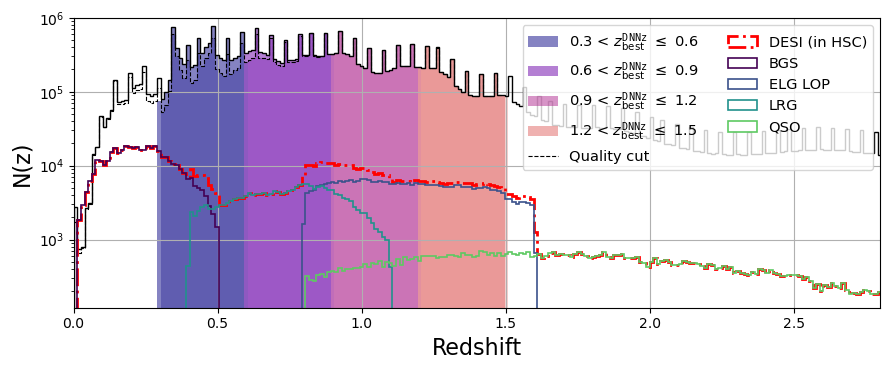

In [14]:
fig, ax = plt.subplots(figsize=(9, 3.8))
global_bins = np.linspace(0, np.nanmax(photoz), 490) 
quality_mask = (
    ((hsc['dnnz_photoz_err95_max'] - hsc['dnnz_photoz_err95_min']) < 2.7)
    & ((hsc['mizuki_photoz_err95_max'] - hsc['mizuki_photoz_err95_max']) < 2.7)
)

for i, z in enumerate(hsc_bins[:-1]):
    z_mask = (photoz >= z) & (photoz < hsc_bins[i + 1])
    ax.hist(
        photoz[z_mask], 
        bins=global_bins,  
        color=cmap_hsc(i / len(hsc_bins)), 
        label=(
            f'{z:.1f} < ' 
            + r'$z_{\mathrm{best}}^{\mathtt{DNNz}}$' 
            + r' $\leq$' 
            + f' {hsc_bins[i + 1]:.1f}'
        ),
        alpha=0.5
    )
    ax.hist(
        photoz[zbin == i + 1], 
        bins=global_bins,  
        color=cmap_hsc(i / len(hsc_bins)), 
        alpha=0.3
    )
ax.hist(
    photoz, 
    bins=global_bins,  
    color='black', 
    histtype='step', 
    linewidth=1, 
    linestyle='-'
    )
shear_selection = (quality_mask & (photoz <= 0.3)) | (zbin > 0)
counts, bins = np.histogram(photoz[shear_selection], bins=global_bins)
# avoid 0s in the histogram
nonzero = np.where(counts > 0)[0]
if len(nonzero) > 0:
    start = nonzero[0]
    end = nonzero[-1]
    ax.step(
        bins[start:end+1][:-1],
        counts[start:end],
        where='post',
        color='black',
        linestyle='--',
        linewidth=0.8,
        label='Quality cut'
    )
ax.hist(
    desi_in_moc['Z'],
    bins=global_bins,
    color='red',
    label='DESI (in HSC)',
    histtype='step',
    linewidth=2,
    linestyle='-.'
)
targets = ['BGS', 'ELG LOP', 'LRG', 'QSO']
for i, t in enumerate(tbls_in_moc):
    ax.hist(
        t['Z'], 
        bins=global_bins, 
        color=cmap_desi(i / len(tbls_in_moc)), 
        label=f'{targets[i]}', 
        histtype='step', 
        linewidth=1.2
    )

ax.set_yscale('log')
ax.set_xlabel('Redshift', fontsize=16)
ax.set_ylabel('N(z)', fontsize=16)
ax.grid(True)
ax.legend(ncols=2, fontsize=10.5, loc='upper right')
ax.set_xlim(0, 2.8)
ax.set_ylim(1.2e2, 1e6)
plt.tight_layout()
plt.savefig(PAPER_FIGURES_ROOT / 'density_z.png')

In [28]:
zbin_index = 1
zbin = hsc[hsc["z_bin"] == zbin_index]
imag = zbin['i_cm_mag']

Processing z-bin 0
Number of objects in z-bin 0: 9146157
Processing z-bin 1
Number of objects in z-bin 1: 5889826
Processing z-bin 2
Number of objects in z-bin 2: 8445233
Processing z-bin 3
Number of objects in z-bin 3: 7023314
Processing z-bin 4
Number of objects in z-bin 4: 3902504
Processing z-bin 5
Number of objects in z-bin 5: 34407034


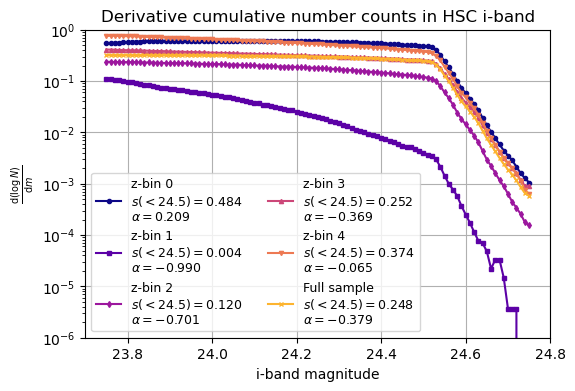

In [72]:
plt.figure(figsize=(6, 4))
mag_bins = np.linspace(23.75, 24.75, 101)
def cumulative_mag_counts(mag, ibmag):
    """Cumulative number counts for magnification bias."""
    return np.array([np.sum(ibmag < m) for m in mag])

dmag = np.gradient(mag_bins)
markers = ['o', 's', 'd', '^', 'v', 'x']
for zbin_index in range(0, 6):
    print(f'Processing z-bin {zbin_index}')
    if zbin_index == 5:
        zbin = hsc
        imag = hsc['i_cm_mag'][:]
    else:
        zbin = hsc[hsc["z_bin"] == zbin_index]
        imag = zbin['i_cm_mag']
    print(f'Number of objects in z-bin {zbin_index}: {len(imag)}')
    mag_counts = cumulative_mag_counts(mag_bins, imag)
    dlog_counts = np.gradient(np.log10(mag_counts))
    derivative = dlog_counts / dmag
    from scipy.interpolate import interp1d
    s_interp = interp1d(mag_bins, derivative, bounds_error=False, fill_value=np.nan)
    s_lim = s_interp(24.5)

    plt.plot(
        mag_bins, 
        derivative, 
        marker=markers[zbin_index],
        markersize=3, 
        label=(
            (f'z-bin {zbin_index}' if zbin_index < 5 else 'Full sample') +
            '\n' +
            rf'$s(< 24.5) = {s_lim:.3f}$' + 
            '\n' +
            rf'$\alpha = {2.5 * s_lim - 1:.3f}$'
        ),
        color=cmap_hsc(zbin_index/6),   
        )
plt.grid(True)
plt.xlabel('i-band magnitude')
plt.ylabel(r'$\frac{\mathrm{d}(\log N)}{\mathrm{d}m}$')
plt.yscale('log')
plt.ylim(1e-6, 1)
plt.title('Derivative cumulative number counts in HSC i-band')
plt.legend(loc='lower left', fontsize=9, ncols=2)

Number of objects in z-bin 0: 9146157
Number of objects in z-bin 1: 5889826
Number of objects in z-bin 2: 8445233
Number of objects in z-bin 3: 7023314
Number of objects in z-bin 4: 3902504
Number of objects in z-bin 5: 34407034


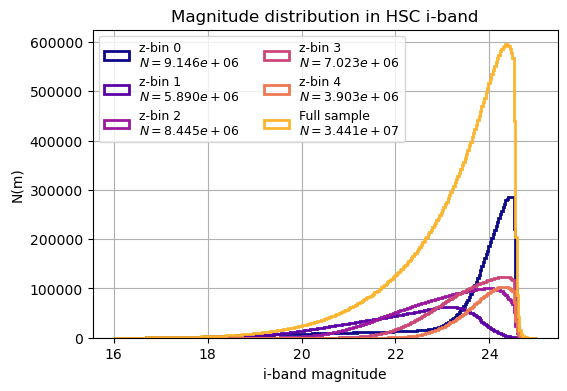

In [70]:
## magnitude distributions for each z-bin
mag_bins_hist = np.linspace(16, 25, 301)
plt.figure(figsize=(6, 4))
for zbin_index in range(0, 6):
    if zbin_index == 5:
        zbin = hsc
        imag = hsc['i_cm_mag'][:]
    else:
        zbin = hsc[hsc["z_bin"] == zbin_index]
        imag = zbin['i_cm_mag']
    print(f'Number of objects in z-bin {zbin_index}: {len(imag)}')
    plt.hist(
        imag, 
        bins=mag_bins_hist, 
        histtype='step', 
        label=(
            (
                f'z-bin {zbin_index}' 
                if zbin_index < 5 
                else 'Full sample'
                )
            + '\n' +
            rf'$N = {len(imag):.3e}$'
        ),
        color=cmap_hsc(zbin_index/6), 
        linewidth=2
    )
plt.grid(True)
plt.xlabel('i-band magnitude')
plt.ylabel('N(m)')
plt.title('Magnitude distribution in HSC i-band')
plt.legend(loc='upper left', fontsize=9, ncols=2)